In [99]:
# Master jupyter notebook for Case Study

In [100]:
# importing libraries
import pandas as pd
import sqlite3
from sklearn.preprocessing import LabelEncoder
import datetime
from forex_python.converter import CurrencyRates
from forex_python.converter import RatesNotAvailableError
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc, f1_score, roc_auc_score, precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier
import joblib
import numpy as np


In [101]:
# saving tables as dataframes
connection = sqlite3.connect("data.db")

client = pd.read_sql_query("SELECT * FROM client;", connection)
client_products = pd.read_sql_query("SELECT * FROM client_products;", connection)
balances = pd.read_sql_query("SELECT * FROM balances;", connection)
inv_campaign_eval = pd.read_sql_query("SELECT * FROM inv_campaign_eval;", connection)

# merging tables with client data (excluding balances and campaign eval table)
connection = sqlite3.connect('data.db')
query = """
    SELECT
        cl.client_id,
        cl.age,
        cl.job,
        cl.marital,
        cl.education,
        cl.gender,
        cp.has_deposits,
        cp.loan,
        cp.has_insurance,
        cp.has_mortgage
    FROM client AS cl
        left join client_products AS cp on cl.client_id = cp.client_id
        """
clients_merged = pd.read_sql_query(query, connection)
connection.close()

In [102]:
# checking for datatypes
print(clients_merged.dtypes)

# checking for missing values
print(client.isnull().sum()) # missing values in Age and Job
print(client_products.isnull().sum()) # no missing values
print(inv_campaign_eval.isnull().sum()) # no missing values
print(balances.isnull().sum()) # no missing values

# dealing with missing values
clients_merged['job'].fillna('unknown', inplace=True) # imputing "unknown" in job
clients_merged['age'].fillna(clients_merged['age'].median(), inplace=True) # imputing median in age

client_id          int64
age              float64
job               object
marital           object
education         object
gender            object
has_deposits      object
loan              object
has_insurance     object
has_mortgage      object
dtype: object
client_id      0
age          232
job          438
marital        0
education      0
gender         0
dtype: int64
client_id        0
has_deposits     0
loan             0
has_insurance    0
has_mortgage     0
dtype: int64
client_id    0
poutcome     0
dtype: int64
date         0
balance      0
client_id    0
currency     0
dtype: int64


In [103]:
print(clients_merged.isnull().sum()) 
print(clients_merged.head()) # no more missing values

client_id        0
age              0
job              0
marital          0
education        0
gender           0
has_deposits     0
loan             0
has_insurance    0
has_mortgage     0
dtype: int64
    client_id   age            job   marital  education gender has_deposits  \
0   249789938  38.0       services   married  secondary      M          yes   
1  1222646323  46.0       services  divorced    unknown      M           no   
2   451375919  33.0         admin.    single  secondary      F           no   
3   338972671  44.0  self-employed   married  secondary      F           no   
4  1472834688  36.0    blue-collar   married    primary      M          yes   

  loan has_insurance has_mortgage  
0   no             n           no  
1   no             n           no  
2   no             n          yes  
3   no             y          yes  
4   no             n          yes  


In [104]:
# label encoding categorical variables, turning them into numerical variables for modeling
le = LabelEncoder()
clients_merged['has_deposits_enc'] = le.fit_transform(clients_merged['has_deposits'])
clients_merged['loan_enc'] = le.fit_transform(clients_merged['loan'])
clients_merged['has_insurance_enc'] = le.fit_transform(clients_merged['has_insurance'])
clients_merged['has_mortgage_enc'] = le.fit_transform(clients_merged['has_mortgage'])
clients_merged['marital_enc'] = le.fit_transform(clients_merged['marital'])
clients_merged['education_enc'] = le.fit_transform(clients_merged['education'])
clients_merged['gender_enc'] = le.fit_transform(clients_merged['gender'])
clients_merged['job_enc'] = le.fit_transform(clients_merged['job'])

In [105]:
# extracting encoding labels for future reference, to be able to decode the encoded variables back to their original values
job_labels = clients_merged[['job', 'job_enc']].drop_duplicates().sort_values('job_enc')
gender_labels = clients_merged[['gender', 'gender_enc']].drop_duplicates().sort_values('gender_enc')
education_labels = clients_merged[['education', 'education_enc']].drop_duplicates().sort_values('education_enc')
marital_labels = clients_merged[['marital', 'marital_enc']].drop_duplicates().sort_values('marital_enc')
has_mortgage_labels = clients_merged[['has_mortgage', 'has_mortgage_enc']].drop_duplicates().sort_values('has_mortgage_enc')
has_insurance_labels = clients_merged[['has_insurance', 'has_insurance_enc']].drop_duplicates().sort_values('has_insurance_enc')
loan_labels = clients_merged[['loan', 'loan_enc']].drop_duplicates().sort_values('loan_enc')
has_deposits_labels = clients_merged[['has_deposits', 'has_deposits_enc']].drop_duplicates().sort_values('has_deposits_enc')

In [106]:
balances['date'] = pd.to_datetime(balances['date'])
print(balances.head())
print(balances.dtypes)

                        date      balance  client_id currency
0 2023-06-06 16:21:15.291346  2680.467773  249789938      CZK
1 2023-05-23 16:21:15.291346  2654.055419  249789938      CZK
2 2023-05-09 16:21:15.291346  2620.835872  249789938      CZK
3 2023-04-25 16:21:15.291346  2720.315925  249789938      CZK
4 2023-04-11 16:21:15.291346  2687.601982  249789938      CZK
date         datetime64[ns]
balance             float64
client_id             int64
currency             object
dtype: object


In [107]:
# editing table balances
# removing time from datetime
balances['date'] = pd.to_datetime(balances['date'])
balances['date'] = balances['date'].dt.date

# fetching currency exchange rates for EUR and USD, as the balances are in different currencies, we need to convert them to the same currency for analysis and modeling, using forex-python library
c = CurrencyRates()

dates = balances['date'].drop_duplicates()
target_currency = 'CZK'

# EUR
base_currency = 'EUR'

# fetching exchange rates for each date and storing them in lists, then creating a dataframe from the lists
eur_rates_date = []
eur_rates_rate = []

for date in dates:
    rate = c.get_rate(base_currency, target_currency, date)
    eur_rates_date.append(date) 
    eur_rates_rate.append(rate)

eur_df = pd.DataFrame({'date': eur_rates_date, 'eur_rate': eur_rates_rate})

# USD
base_currency = 'USD'

usd_rates_date = []
usd_rates_rate = []

for date in dates:
    rate = c.get_rate(base_currency, target_currency, date)
    usd_rates_date.append(date)
    usd_rates_rate.append(rate)

usd_df = pd.DataFrame({'date': usd_rates_date, 'usd_rate': usd_rates_rate})

# mapping exchange rate columns into balances dataframe
balances = pd.merge(balances, eur_df, on = 'date')
balances = pd.merge(balances, usd_df, on = 'date')



In [108]:
# creating column with balances recalculated to czk, using exchange rates, if the currency is EUR, we multiply the balance by the eur_rate, if the currency is USD, we multiply the balance by the usd_rate, if the currency is already in CZK, we keep the balance as it is
for index, row in balances.iterrows(): 
    if row['currency'] == 'EUR':
        balances.at[index, 'fx_rate'] = balances.at[index, 'eur_rate']
    elif row['currency'] == 'USD':
        balances.at[index, 'fx_rate'] = balances.at[index, 'usd_rate']
    else:
        balances.at[index, 'fx_rate'] = 1

balances['balance_in_czk'] = balances['balance']*balances['fx_rate']

In [109]:
# table balances: editing and feature engineering from variables: balance, currency
# encoding outcome variable 
inv_campaign_eval['poutcome_enc'] = le.fit_transform(inv_campaign_eval['poutcome'])

# last balance
last_timestamp_index = balances.groupby('client_id')['date'].idxmax()
last_timestamp_df = balances.loc[last_timestamp_index]
last_timestamp_df.rename(columns={'balance_in_czk': 'last_balance'}, inplace=True)
clients_merged = pd.merge(clients_merged, last_timestamp_df[['last_balance','client_id']], on = 'client_id')

# mean balance
mean_bal_by_client = balances.groupby('client_id')['balance_in_czk'].mean().reset_index()
mean_bal_by_client.rename(columns={'balance_in_czk': 'mean_balance'}, inplace=True)
clients_merged = pd.merge(clients_merged, mean_bal_by_client[['mean_balance','client_id']], on = 'client_id')

# min balance
min_bal_by_client = balances.groupby('client_id')['balance_in_czk'].min().reset_index()
min_bal_by_client.rename(columns={'balance_in_czk': 'min_balance'}, inplace=True)
clients_merged = pd.merge(clients_merged, min_bal_by_client[['min_balance','client_id']], on = 'client_id')

# max balance
max_bal_by_client = balances.groupby('client_id')['balance_in_czk'].max().reset_index()
max_bal_by_client.rename(columns={'balance_in_czk': 'max_balance'}, inplace=True)
clients_merged = pd.merge(clients_merged, max_bal_by_client[['max_balance','client_id']], on = 'client_id')

# currency (encoded)
clients_merged = pd.merge(clients_merged, balances[['client_id','currency']].drop_duplicates(), on = 'client_id')
clients_merged['currency_enc'] = le.fit_transform(clients_merged['currency'])
currency_labels = clients_merged[['currency', 'currency_enc']].drop_duplicates().sort_values('currency_enc')

In [110]:
# creating table first round of campaign - encoded columns (for modeling)
first_round_clients = clients_merged[['client_id', 'age', 'has_deposits_enc', 'loan_enc', 'has_insurance_enc', 'has_mortgage_enc','marital_enc', 'education_enc', 'gender_enc', 'job_enc', 'last_balance','mean_balance', 'min_balance', 'max_balance', 'currency_enc']]
first_round_clients = pd.merge(inv_campaign_eval[['client_id','poutcome_enc']], first_round_clients, on = 'client_id')
first_round_clients['age'] = first_round_clients['age'].astype(int)

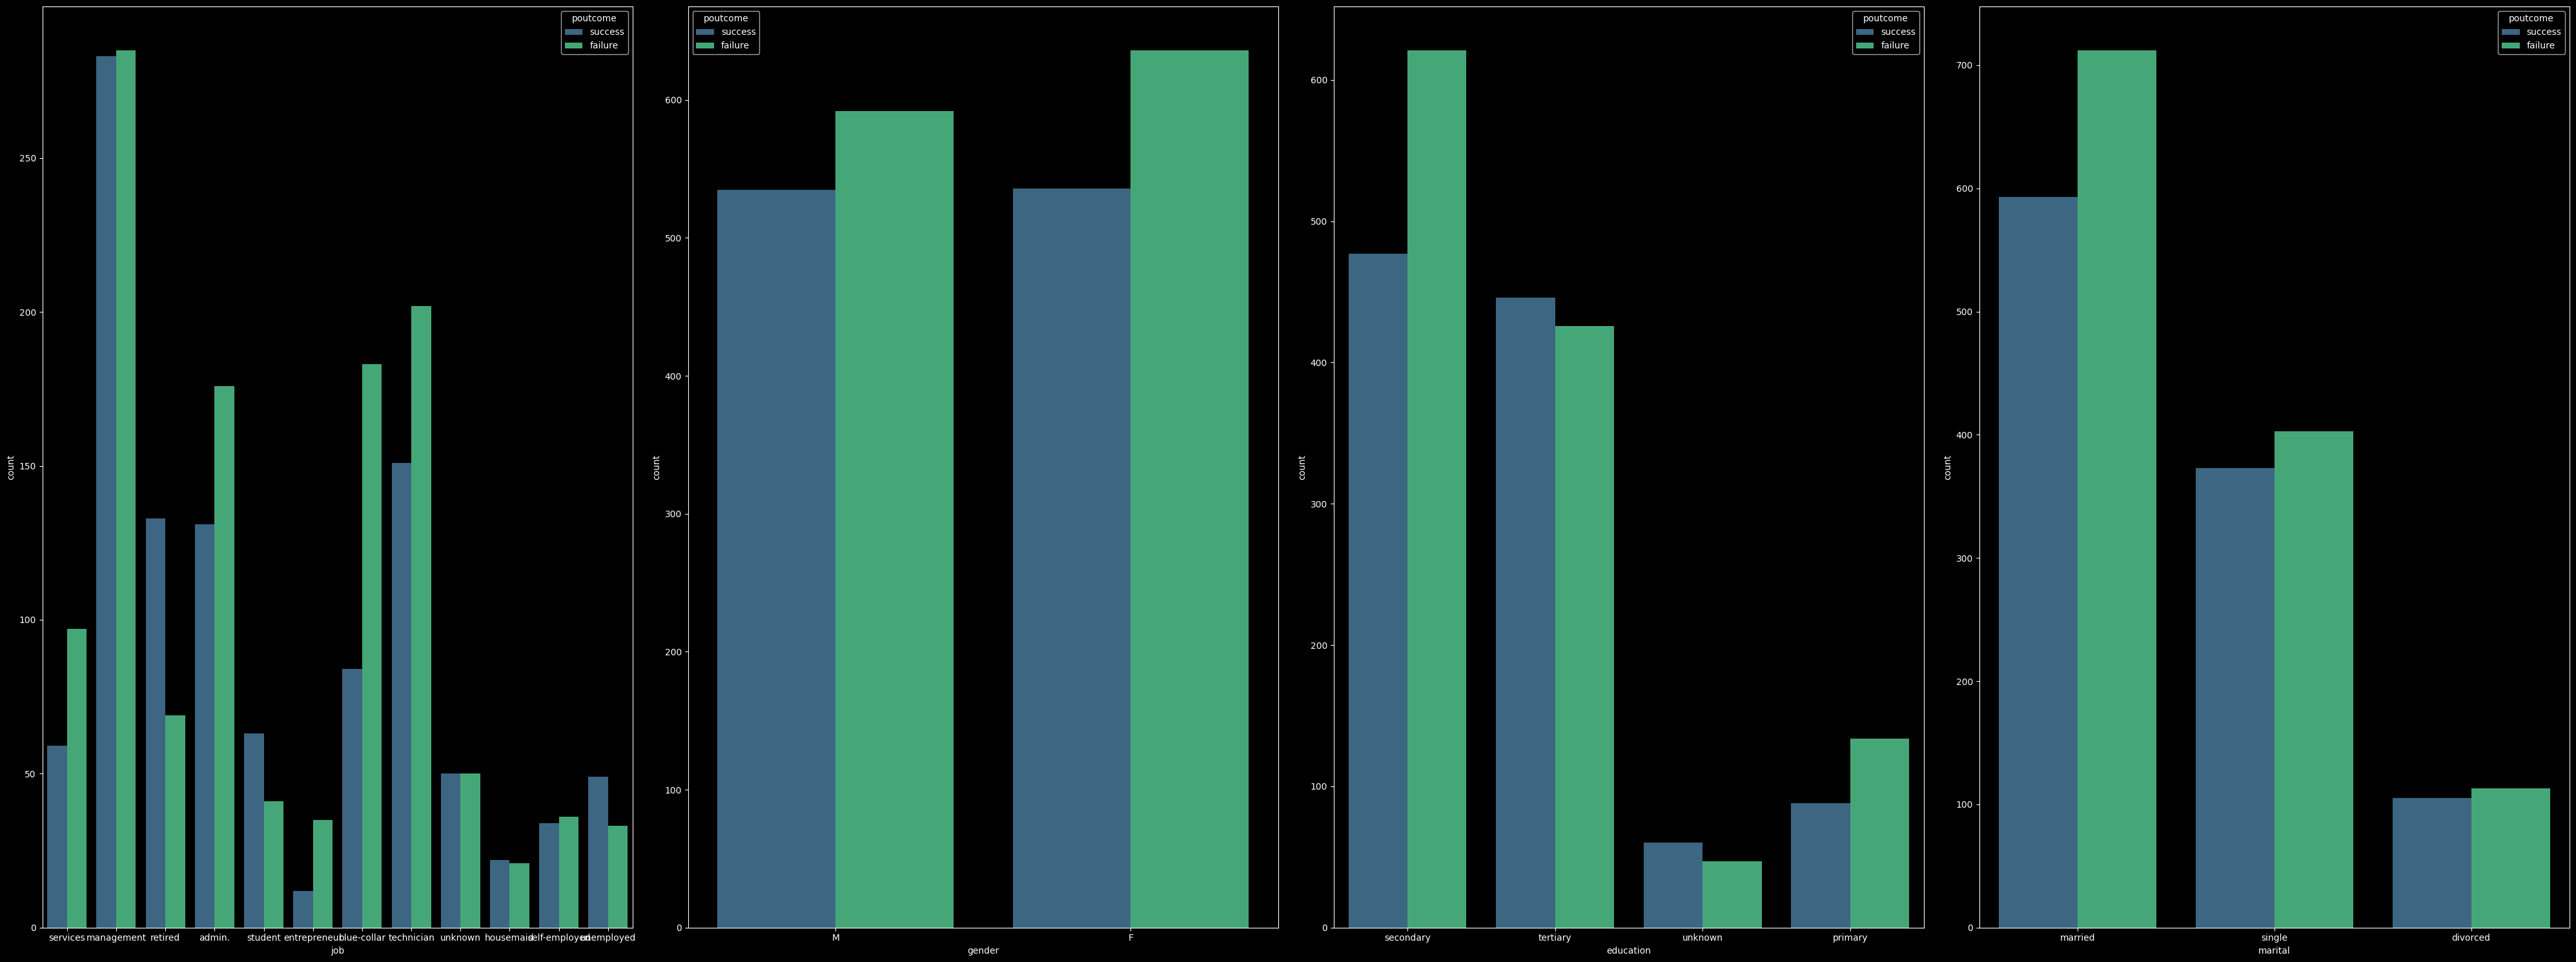

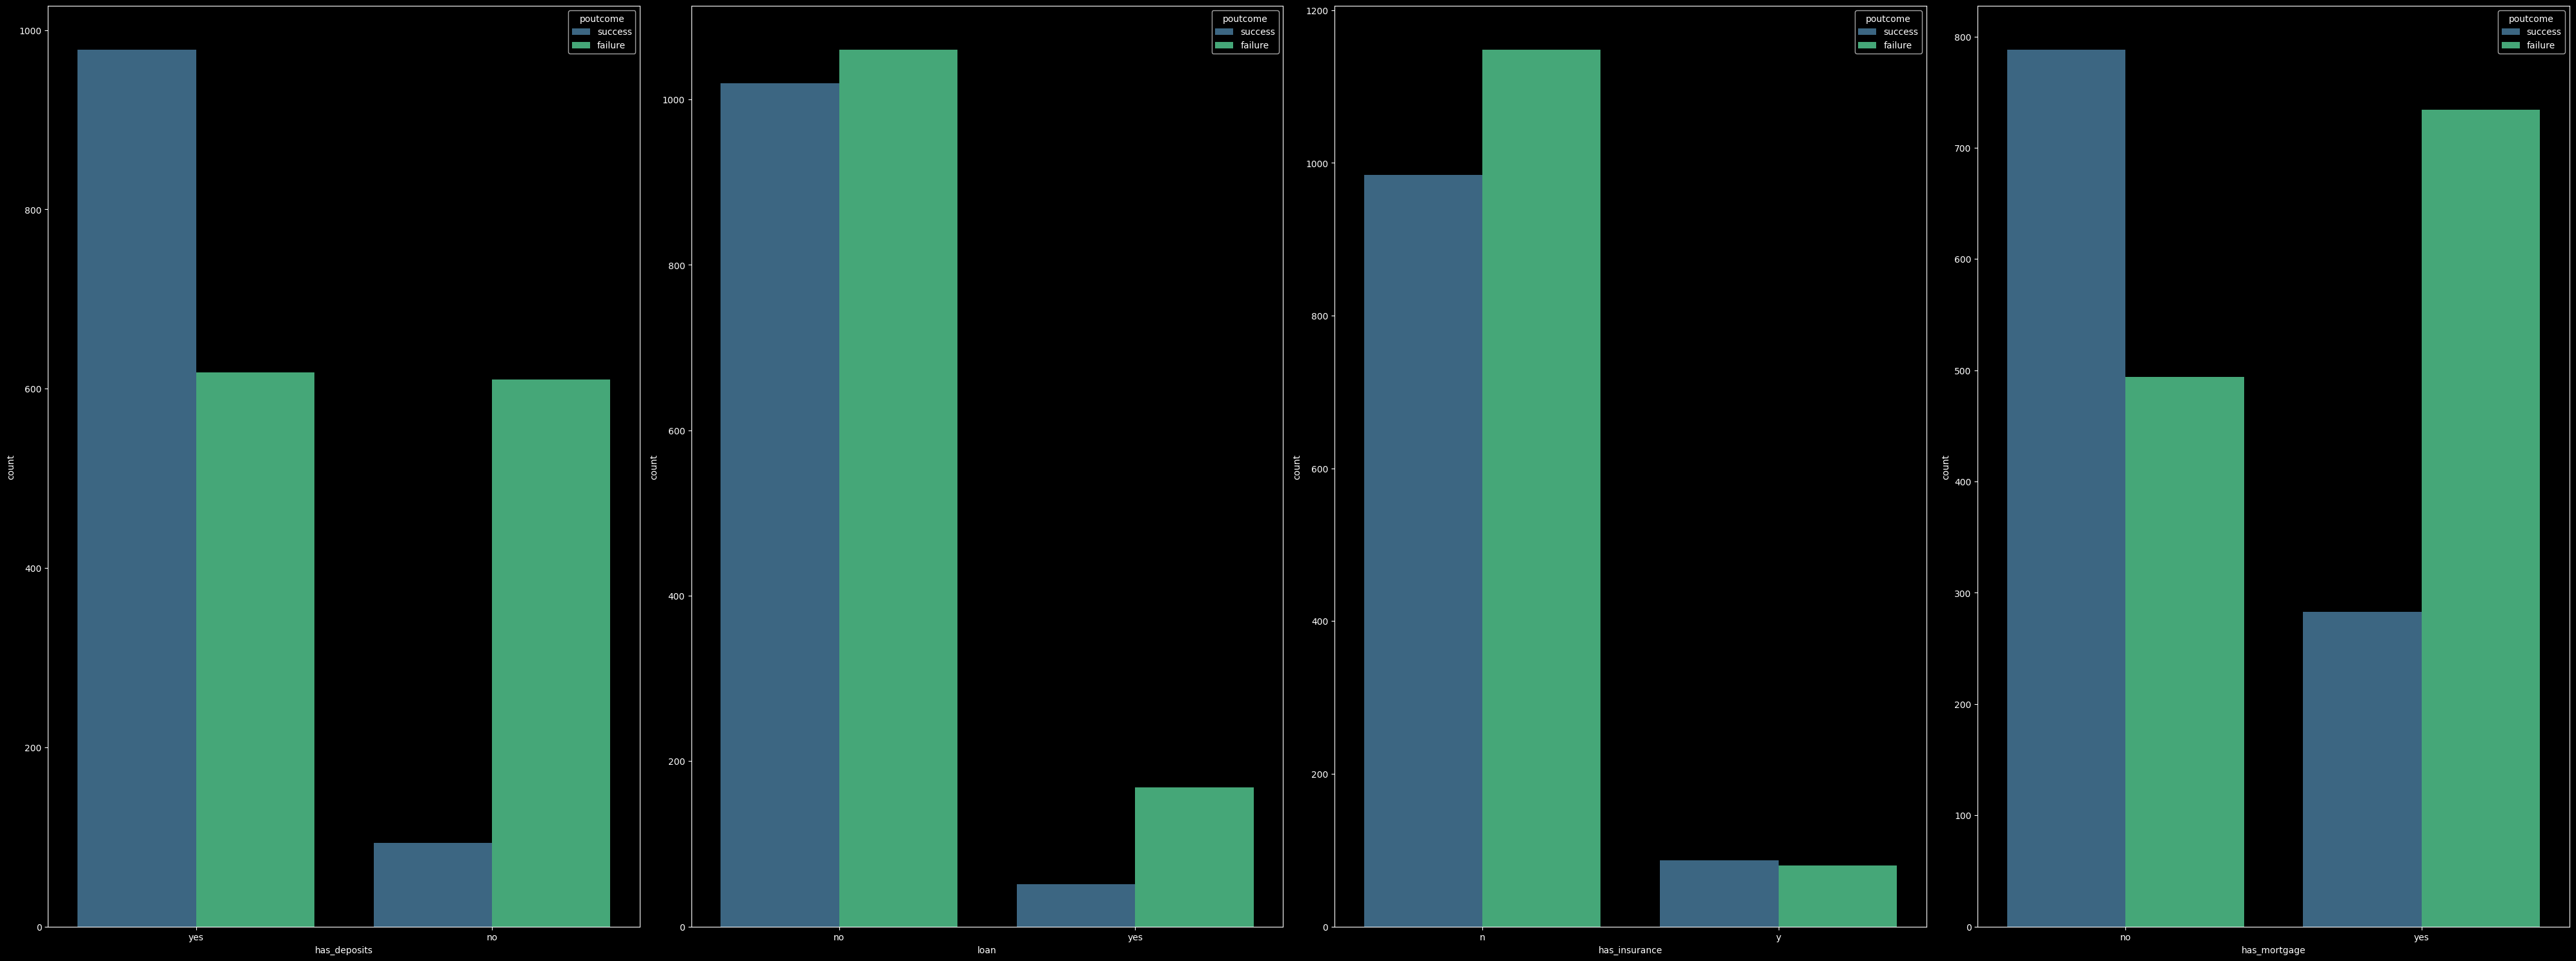

In [111]:
# visualizations of data from first round of campaign

plt.figure(figsize=(40, 15))

plt.subplot(1, 4, 1)
sns.countplot(x='job', hue='poutcome', data=first_round_vis, palette='viridis')

plt.subplot(1, 4, 2)
sns.countplot(x='gender', hue='poutcome', data=first_round_vis, palette='viridis')

plt.subplot(1, 4, 3)
sns.countplot(x='education', hue='poutcome', data=first_round_vis, palette='viridis')

plt.subplot(1, 4, 4)
sns.countplot(x='marital', hue='poutcome', data=first_round_vis, palette='viridis')

plt.tight_layout()
plt.show()
# ------------------------------------------------------------------------------------------
plt.figure(figsize=(40, 15))

plt.subplot(1, 4, 1)
sns.countplot(x='has_deposits', hue='poutcome', data=first_round_vis, palette='viridis')

plt.subplot(1, 4, 2)
sns.countplot(x='loan', hue='poutcome', data=first_round_vis, palette='viridis')

plt.subplot(1, 4, 3)
sns.countplot(x='has_insurance', hue='poutcome', data=first_round_vis, palette='viridis')

plt.subplot(1, 4, 4)
sns.countplot(x='has_mortgage', hue='poutcome', data=first_round_vis, palette='viridis')

plt.tight_layout()
plt.show()

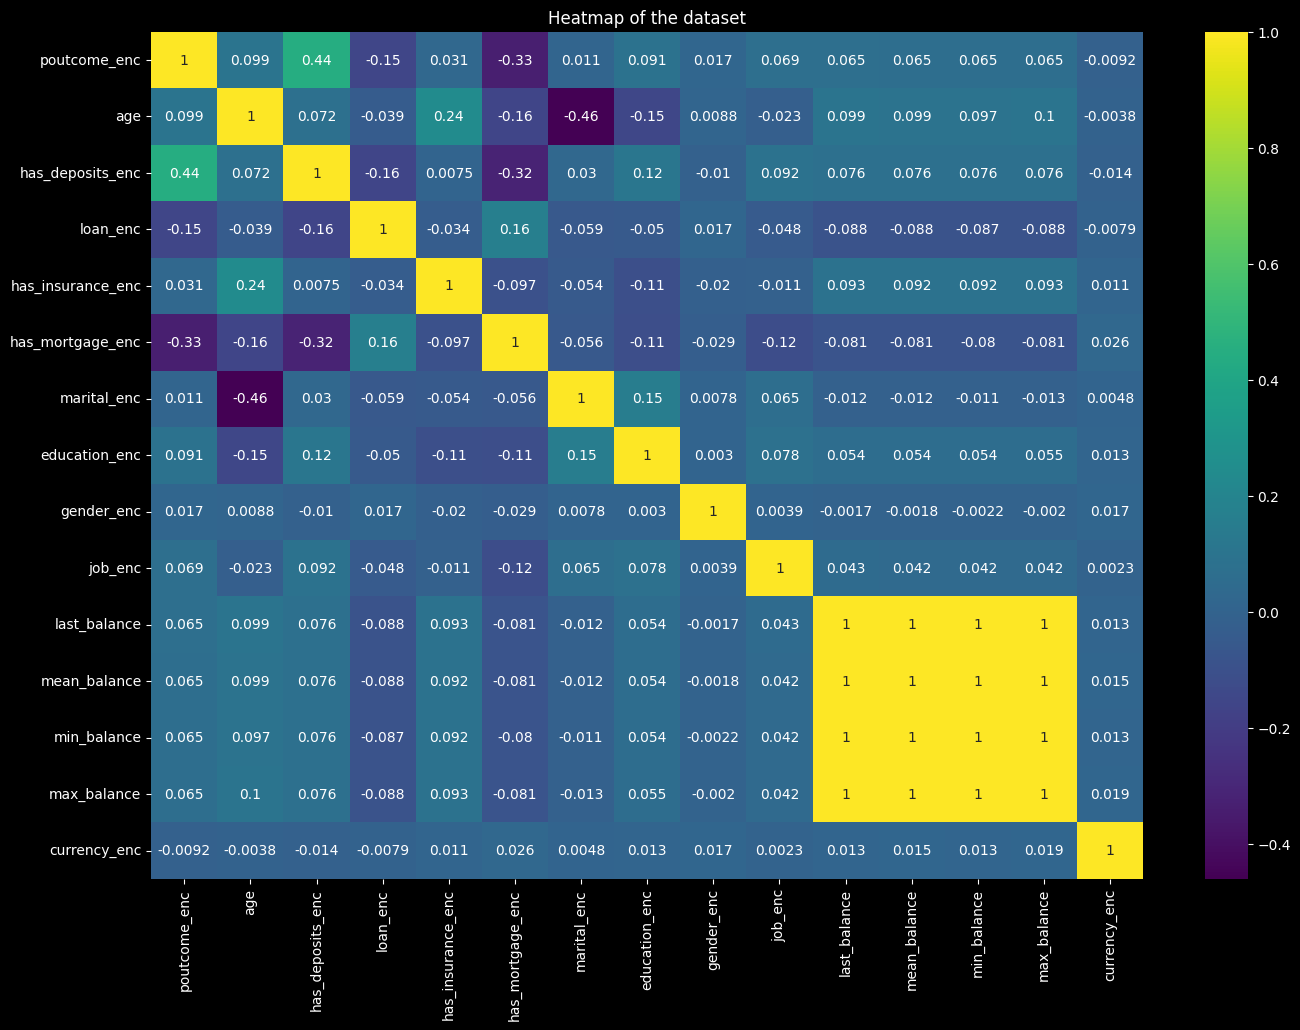

In [112]:
# CORRELATION MATRIX
# Calculating the correlation matrix
corr = first_round_clients.iloc[:,1:].corr()
# Plotting the correlation matrix
plt.figure(figsize=(16,11))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title('Heatmap of the dataset')
plt.show()

In [113]:
# creating X-matrix of predictors and y-outcome variable
X = first_round_clients.drop(['client_id','poutcome_enc'], axis = 1) # removing client_id and poutcome_enc from predictors, as client_id is just an identifier and poutcome_enc is the outcome variable, axis = 1 means we are dropping columns
y = first_round_clients['poutcome_enc'] # the outcome variable is poutcome_enc, which is the encoded version of poutcome, where 0 means "failure", 1 means "other" and 2 means "success"

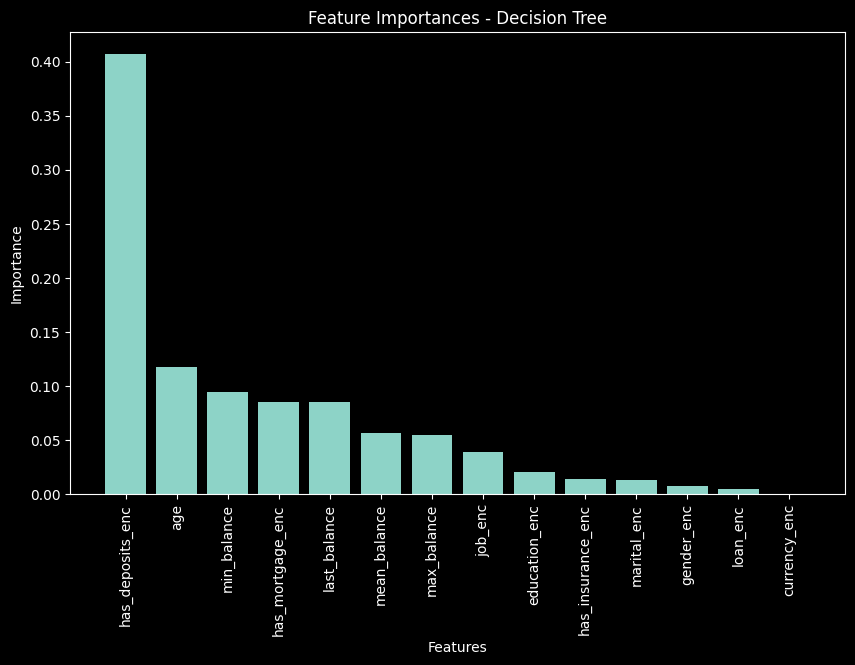

In [114]:
# selecting most important features from X using feature importance
classifier = DecisionTreeClassifier(max_depth=10, min_samples_split=4)

classifier.fit(X, y)
importances = classifier.feature_importances_
feature_names = ['age', 'has_deposits_enc', 'loan_enc', 'has_insurance_enc', 'has_mortgage_enc',
                     'marital_enc', 'education_enc', 'gender_enc', 'job_enc', 'last_balance',
                     'mean_balance', 'min_balance', 'max_balance', 'currency_enc']

sorted_data = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse = True)
sorted_feature_names, sorted_importances = zip(*sorted_data)

# Set dark theme
plt.style.use('dark_background')
# Set custom rcParams for dark theme
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

plt.figure(figsize=(10, 6))
plt.title('Feature Importances - Decision Tree')
plt.bar(sorted_feature_names, sorted_importances, align="center")
plt.xticks(sorted_feature_names, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# based on decision tree and feature importances, we consider as most important these variables:
# 'has_deposits_enc', 'age', 'last_balance','min_balance', 'has_mortgage_enc','max_balance','mean_balance','job_enc'
X = X[['has_deposits_enc', 'age', 'last_balance','min_balance', 'has_mortgage_enc','max_balance','mean_balance','job_enc']]

In [115]:
# performing train-test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

In [116]:
# Logistic Regression
# Define the Logistic Regression model
logistic_classifier = LogisticRegression()

# Define the hyperparameter grid to search over
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga']
}

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=logistic_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the data
grid_search.fit(X_train_sc, y_train)

# Get the best estimator
best_lr_estimator = grid_search.best_estimator_


/Users/zuzana/anaconda3/envs/gaps/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zuzana/anaconda3/envs/gaps/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zuzana/anaconda3/envs/gaps/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zuzana/anaconda3/envs/gaps/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zuzana/anaconda3/envs/gaps/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zuz

In [117]:
# KNN
# Define the KNN classifier
knn_classifier = KNeighborsClassifier()

# Define the hyperparameter grid to search over
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=knn_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the data
grid_search.fit(X_train_sc, y_train)

# Get the best estimator
best_knn_estimator = grid_search.best_estimator_


In [118]:
# Random Forest
# Define the Random Forest classifier
rf_classifier = RandomForestClassifier()

# Define the hyperparameter grid to search over
param_grid = {
    'n_estimators': [20, 50, 100],
    'max_depth': [None, 2, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the data
grid_search.fit(X_train_sc, y_train)

# Get the best estimator
best_rf_estimator = grid_search.best_estimator_

In [119]:
# Adaboost
# Define the Adaboost classifier
adaboost = AdaBoostClassifier()

# Define the hyperparameter grid to search over
adaboost_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2)]
}

# Create GridSearchCV object
grid_search = GridSearchCV(adaboost, adaboost_grid, cv=5, scoring='accuracy')

# Fit the GridSearchCV object to the data
grid_search.fit(X_train_sc, y_train)

# Get the best estimator
best_adaboost_estimator = grid_search.best_estimator_


In [120]:
# Neural Network
nn = Sequential([
    Input(shape = (8,)),
    Dense(32, activation = "tanh"),
    Dense(32, activation = "tanh"),
    Dense(1, activation = "sigmoid")

])

nn.compile(loss="binary_crossentropy", optimizer='adam', metrics=['accuracy'])

history = nn.fit(X_train_sc, y_train, epochs=100, batch_size=32, verbose = 0, validation_split=0.1)

# manually calculating metrics for test data
y_pred_nn_test = nn.predict(X_test_sc)
y_pred_binary_test = (y_pred_nn_test > 0.5).astype(int)
f1_nn = f1_score(y_test, y_pred_binary_test)

roc_auc_nn = roc_auc_score(y_test, y_pred_nn_test)

precision_nn, recall_nn, _nn = precision_recall_curve(y_test, y_pred_nn_test)
pr_auc_nn = auc(recall_nn, precision_nn)

acc_nn_test = accuracy_score(y_test, y_pred_binary_test)

# manually calculating metrics for train data
y_pred_nn_train = nn.predict(X_train_sc)
y_pred_binary_train = (y_pred_nn_train > 0.5).astype(int)
f1_nn_train = f1_score(y_train, y_pred_binary_train)

roc_auc_nn_train = roc_auc_score(y_train, y_pred_nn_train)

precision_nn, recall_nn, _nn = precision_recall_curve(y_train, y_pred_nn_train)
pr_auc_nn_train = auc(recall_nn, precision_nn)

acc_nn_train = accuracy_score(y_train, y_pred_binary_train)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step


In [121]:
# run on Test data - compare models on F1, AUC - choose best model

classifiers = [best_rf_estimator, best_lr_estimator, best_knn_estimator, best_adaboost_estimator]
classifier_names = ['Random Forest', 'Logistic Regression', 'KNN', 'Adaboost']

# Define metrics
metrics = {'F1 Score': f1_score, 'AUC-ROC': roc_auc_score}

# Collect results
results_on_test = {}

for classifier, name in zip(classifiers, classifier_names):
    # F1 Score
    y_pred = classifier.predict(X_test_sc)
    f1 = f1_score(y_test, y_pred)
    
    # AUC-ROC
    y_scores = classifier.predict_proba(X_test_sc)[:, 1]
    roc_auc = roc_auc_score(y_test, y_scores)
    
    # AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    results_on_test[name] = {'F1 Score': f1, 'AUC-ROC': roc_auc, 'AUC-PR': pr_auc, 'Accuracy': accuracy,'y_scores': y_scores}

results_on_test['Neural network'] = {'F1 Score': f1_nn, 'AUC-ROC': roc_auc_nn, 'AUC-PR': pr_auc_nn, 'Accuracy': acc_nn_test, 'y_scores': y_pred_nn_test}

# Print results
for name, metrics_dict in results_on_test.items():
    print(f"\n{name} Metrics:")
    for metric, value in metrics_dict.items():
        print(f"{metric}: {value}")

# printing metrics results
results_on_test_metrics = pd.DataFrame(results_on_test).iloc[0:4,:]



Random Forest Metrics:
F1 Score: 0.6811819595645412
AUC-ROC: 0.7436599715966729
AUC-PR: 0.6383738696852995
Accuracy: 0.7028985507246377
y_scores: [0.62148592 0.56683159 0.73221426 0.63151667 0.46056244 0.3733977
 0.17968053 0.42528623 0.74127127 0.18956878 0.44987365 0.64347185
 0.59124077 0.15793346 0.60942221 0.14538831 0.40682738 0.65304925
 0.4186946  0.45824955 0.64777163 0.41997954 0.42094787 0.6376776
 0.33628247 0.64323294 0.45636092 0.64631942 0.17925932 0.59786387
 0.443784   0.60203546 0.43506751 0.33268196 0.61353317 0.19373468
 0.69995837 0.65265795 0.20844665 0.14538831 0.19164595 0.69950924
 0.19990487 0.29674528 0.64869103 0.64841055 0.64914432 0.63442483
 0.44055666 0.18746904 0.17821093 0.33663018 0.41225859 0.64953132
 0.62191492 0.33222392 0.60188768 0.17723441 0.64196431 0.42315588
 0.62437759 0.42220351 0.44216868 0.66107964 0.63901653 0.22301142
 0.66056964 0.59078497 0.2244886  0.15928007 0.16768788 0.43943382
 0.42958452 0.61667191 0.42199926 0.64705182 0.1537

In [122]:
# Collect results on train data
results_on_train = {}

for classifier, name in zip(classifiers, classifier_names):
    # F1 Score
    y_pred = classifier.predict(X_train_sc)
    f1_train = f1_score(y_train, y_pred)
    
    # AUC-ROC
    y_scores_train = classifier.predict_proba(X_train_sc)[:, 1]
    roc_auc_train = roc_auc_score(y_train, y_scores_train)
    
    # AUC-PR
    precision, recall, _ = precision_recall_curve(y_train, y_scores_train)
    pr_auc_train = auc(recall, precision)

    # Accuracy
    accuracy = accuracy_score(y_train, y_pred)
    
    results_on_train[name] = {'F1 Score': f1_train, 'AUC-ROC': roc_auc_train, 'AUC-PR': pr_auc_train, 'Accuracy': accuracy, 'y_scores': y_scores_train}

results_on_train['Neural network'] = {'F1 Score': f1_nn_train, 'AUC-ROC': roc_auc_nn_train, 'AUC-PR': pr_auc_nn_train, 'Accuracy': acc_nn_train,'y_scores': y_pred_nn_train}

# printing metrics results
results_on_train_metrics = pd.DataFrame(results_on_train).iloc[0:4,:]


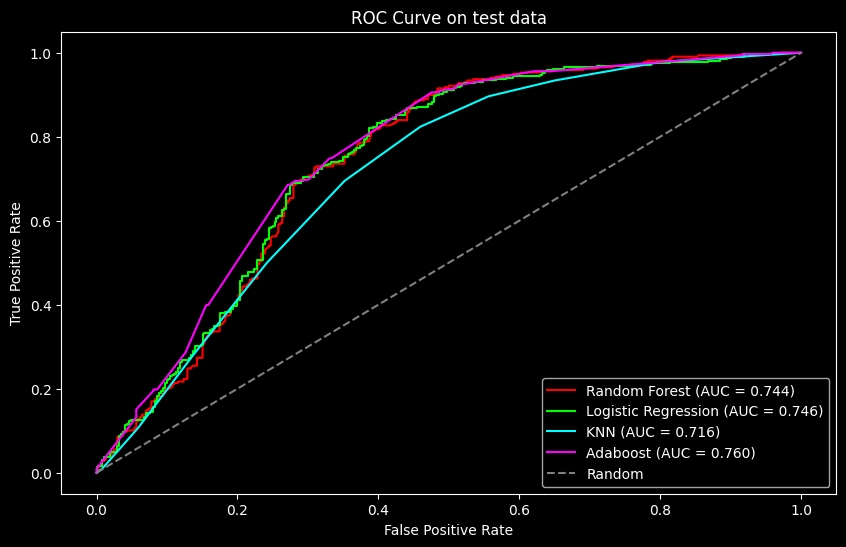

In [123]:
# ROC Curve on test
#classifiers = [best_rf_estimator, best_lr_estimator, best_knn_estimator, best_adaboost_estimator, nn]
#classifier_names = ['Random Forest', 'Logistic Regression', 'KNN', 'Adaboost', 'Neural network']

# Set dark theme
plt.style.use('dark_background')
# Set custom rcParams for dark theme
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

plt.figure(figsize=(10, 6))

line_colors = ['red', 'lime', 'cyan', 'magenta', 'yellow']

for classifier, name, color in zip(classifiers, classifier_names, line_colors):
    fpr, tpr, _ = roc_curve(y_test, results_on_test[name]['y_scores'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results_on_test[name]['AUC-ROC']:.3f})", color=color)

plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.title('ROC Curve on test data')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


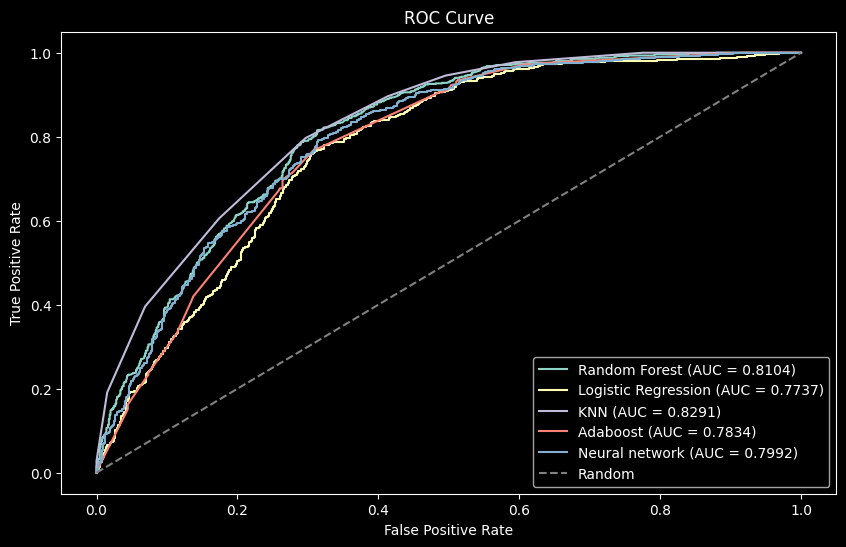

In [124]:
# ROC Curve on train
classifiers = [best_rf_estimator, best_lr_estimator, best_knn_estimator, best_adaboost_estimator, nn]
classifier_names = ['Random Forest', 'Logistic Regression', 'KNN', 'Adaboost', 'Neural network']

plt.figure(figsize=(10, 6))
for classifier, name in zip(classifiers, classifier_names):
    fpr, tpr, _ = roc_curve(y_train, results_on_train[name]['y_scores'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results_on_train[name]['AUC-ROC']:.4f})")

plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [125]:
results_on_test_metrics.applymap(lambda x: round(x, 3))

/var/folders/r9/t715d22j3k38ct_gwg7sm0xc0000gn/T/ipykernel_37498/876586444.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_on_test_metrics.applymap(lambda x: round(x, 3))


,Random Forest,Logistic Regression,KNN,Adaboost,Neural network
F1 Score,0.681,0.679,0.660,0.681,0.683
AUC-ROC,0.744,0.746,0.716,0.760,0.735
AUC-PR,0.638,0.646,0.610,0.681,0.625
Accuracy,0.703,0.700,0.670,0.699,0.690


In [126]:

results_on_train_metrics

,Random Forest,Logistic Regression,KNN,Adaboost,Neural network
F1 Score,0.706737,0.693527,0.746733,0.703728,0.722816
AUC-ROC,0.810358,0.773729,0.829109,0.783379,0.799225
AUC-PR,0.753595,0.695897,0.800771,0.707119,0.733563
Accuracy,0.724052,0.711622,0.747048,0.718459,0.725917


In [127]:
# editing data of clients not included in first run
# preparing data for second round of campaign
second_round_ids = clients_merged.loc[~clients_merged['client_id'].isin(inv_campaign_eval['client_id']), 'client_id']
clients_merged_second = clients_merged[clients_merged['client_id'].isin(second_round_ids)]
second_X = clients_merged_second[['has_deposits_enc', 'age', 'last_balance', 'min_balance', 'has_mortgage_enc', 'max_balance', 'mean_balance', 'job_enc']]

second_X_sc = scaler.transform(second_X)

In [128]:
# run best model on data not included in first run - output predict_proba - select 3000 ids
second_y_pred = best_lr_estimator.predict_proba(second_X_sc)[:,1]

id_results = {'client_id': second_round_ids, 'y_proba': second_y_pred}
id_results = pd.DataFrame(id_results)

id_results_3000 = id_results.sort_values('y_proba', ascending=False).head(3000)
clients_3000 = pd.merge(id_results_3000, clients_merged, on = 'client_id')

In [129]:
# calculate expected number of successes (client will in fact invest in our product)
ex_success = id_results_3000['y_proba'].sum()

# calculate expected revenue for different amounts of investment
ex_rev_5000 = sum(5000*clients_3000['y_proba'])
ex_rev_2000 = sum(2000*clients_3000['y_proba'])

print(ex_success, ex_rev_5000, ex_rev_2000)

1930.069616393152 9650348.081965737 3860139.2327863006


In [130]:
second_phase_outcome = pd.read_csv('second_phase_target_labeled.csv')[['client_id','poutcome']]
clients_3000 = pd.read_csv('clients_3000.csv')

In [131]:
clients_8800 = pd.merge(id_results, clients_merged, on = 'client_id')
df_sample = clients_8800.sample(n=3000, random_state=42)

ex_successs = df_sample['y_proba'].sum()
print(ex_successs)

print(ex_success)

pocet = second_phase_outcome['poutcome'].sum()
pocet/ex_success*ex_successs

1007.5814596163443
1930.069616393152


719.3767725052348

In [132]:
clients_8800

,client_id,y_proba,age,job,marital,education,gender,has_deposits,loan,has_insurance,...,marital_enc,education_enc,gender_enc,job_enc,last_balance,mean_balance,min_balance,max_balance,currency,currency_enc
0,1222646323,0.227109,46.0,services,divorced,unknown,M,no,no,n,...,0,3,1,7,1005.302876,960.562073,886.126906,1054.517907,CZK,0
1,451375919,0.084436,33.0,admin.,single,secondary,F,no,no,n,...,2,1,0,0,1100.917203,1221.016419,1100.917203,1303.494818,CZK,0
2,338972671,0.090614,44.0,self-employed,married,secondary,F,no,no,y,...,1,1,0,6,357.676547,297.993265,202.053088,446.676191,CZK,0
3,1472834688,0.438715,36.0,blue-collar,married,primary,M,yes,no,n,...,1,0,1,1,1906.382731,1919.318145,1853.387429,2011.939205,CZK,0
4,1068680340,0.508028,63.0,admin.,married,secondary,F,yes,no,n,...,1,1,0,0,27.197528,0.972130,-104.261740,77.806737,CZK,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8858,440873221,0.249281,56.0,management,divorced,tertiary,F,no,no,n,...,0,2,0,4,412.546184,386.995526,270.665696,469.647273,CZK,0
8859,543198889,0.088576,40.0,blue-collar,single,unknown,M,no,no,n,...,2,3,1,1,5.538113,18.441905,-98.265981,125.568092,CZK,0
8860,458558558,0.088982,41.0,housemaid,divorced,primary,F,no,no,n,...,0,0,0,3,70.463701,25.552707,-117.991255,116.816943,CZK,0
8861,1426334329,0.112608,59.0,technician,married,primary,F,no,no,y,...,1,0,0,9,3232.008038,3157.720202,3024.384824,3263.371390,CZK,0


In [133]:
# Exporting semi results into csv

# csv_file_path = 'id_results.csv'
# id_results.to_csv(csv_file_path, index=False)

# csv_file_path = 'clients_3000.csv'
# clients_3000.to_csv(csv_file_path, index=False)

# joblib.dump(scaler, 'standard_scaler.joblib')

# joblib.dump(best_rf_estimator, 'best_rf_estimator.joblib')
# joblib.dump(best_lr_estimator, 'best_lr_estimator.joblib')
# joblib.dump(best_knn_estimator, 'best_knn_estimator.joblib')
# joblib.dump(best_adaboost_estimator, 'best_adaboost_estimator.joblib')
# joblib.dump(nn, 'nn.joblib')

# np.save('X_test_sc.npy', X_test_sc)
# np.save('X_train_sc.npy', X_train_sc)

# X_test.to_csv('X_test.csv', index=False)
# X_train.to_csv('X_train.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)

# results_on_train_metrics.to_csv('results_on_train_metrics.csv', index=False)
# results_on_test_metrics.to_csv('results_on_test_metrics.csv', index=False)

# y_scores_nn_train = results_on_train['Neural network']['y_scores'].flatten()
# y_scores_rf_train = results_on_train['Random Forest']['y_scores']
# y_scores_lr_train = results_on_train['Logistic Regression']['y_scores']
# y_scores_knn_train = results_on_train['KNN']['y_scores']
# y_scores_adaboost_train = results_on_train['Adaboost']['y_scores']

# y_scores_nn_test = results_on_test['Neural network']['y_scores'].flatten()
# y_scores_rf_test = results_on_test['Random Forest']['y_scores']
# y_scores_lr_test = results_on_test['Logistic Regression']['y_scores']
# y_scores_knn_test = results_on_test['KNN']['y_scores']
# y_scores_adaboost_test = results_on_test['Adaboost']['y_scores']

# np.save('y_scores_nn_train.npy', y_scores_nn_train)
# np.save('y_scores_rf_train.npy', y_scores_rf_train)
# np.save('y_scores_lr_train.npy', y_scores_lr_train)
# np.save('y_scores_knn_train.npy', y_scores_knn_train)
# np.save('y_scores_adaboost_train.npy', y_scores_adaboost_train)

# np.save('y_scores_nn_test.npy', y_scores_nn_test)
# np.save('y_scores_rf_test.npy', y_scores_rf_test)
# np.save('y_scores_lr_test.npy', y_scores_lr_test)
# np.save('y_scores_knn_test.npy', y_scores_knn_test)
# np.save('y_scores_adaboost_test.npy', y_scores_adaboost_test)
